In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Create project folder
!mkdir -p /content/drive/MyDrive/dementia_risk_project/data/raw
!mkdir -p /content/drive/MyDrive/dementia_risk_project/data/processed
!mkdir -p /content/drive/MyDrive/dementia_risk_project/src
!mkdir -p /content/drive/MyDrive/dementia_risk_project/results

# Symlink for easy access
!ln -sf /content/drive/MyDrive/dementia_risk_project /content/dementia_risk_project
%cd /content/dementia_risk_project

Mounted at /content/drive
/content/drive/MyDrive/dementia_risk_project


In [2]:
!pip install pandas numpy tqdm scikit-learn torch transformers datasets sentence-transformers xgboost matplotlib seaborn statsmodels -q
!pip uninstall -y sympy
!pip install sympy==1.12

Found existing installation: sympy 1.14.0
Uninstalling sympy-1.14.0:
  Successfully uninstalled sympy-1.14.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 22.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cpu requires sympy>=1.13.3, but you have sympy 1.12 which is incompatible.


In [ ]:
from huggingface_hub import snapshot_download
import os

# Download the dataset (this may take 5-10 minutes)
print("Downloading PMC-Patients dataset...")
snapshot_download(repo_id="zhengyun21/PMC-Patients",
                  local_dir="/content/dementia_risk_project/data/raw/pmc_patients",
                  repo_type="dataset")

print("Download complete!")

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Download complete!


In [4]:
# imports
import json
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, recall_score
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler


In [92]:
# load patient data and match with patient uid
with open("data/processed/filtered_patients.json", "r") as f:
    patients = json.load(f)

# load llm features
llm_features = pd.read_csv("llm_extracted_features.csv")
llm_features = llm_features.rename(columns = {"patient_id":"patient_uid"})

# load regex-extracted features
regex_features = pd.read_csv("regex_extracted_features.csv")

# match pmc dataset with patient uid
df_patients = pd.DataFrame(patients)

matching_patient_df = pd.merge(
    llm_features,
    df_patients[['patient_uid', 'label_dementia', 'patient']],
    on='patient_uid',
    how='left'
)

# Create labels
y = matching_patient_df['label_dementia'].to_numpy()

In [93]:
# Create ablation study datasets

# Structured-only baseline (age + sex from LLM extraction)
X0 = llm_features[["age_years"]].fillna(70).values  # Default age 70 for missing
X0_sex = (llm_features["sex"] == "M").fillna(False).astype(int).values.reshape(-1, 1)
X0 = np.hstack([X0, X0_sex])

# Add text embeddings
print("Generating text embeddings...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
# texts = [p.get("patient", "")[:1000] for p in patients[:len(llm_features)]]
texts = matching_patient_df['patient'].to_numpy()
embeddings = embedder.encode(texts, show_progress_bar=True)

X1 = np.hstack([X0, embeddings])

# LLM-extracted binary features
binary_cols = ["hypertension", "brain_injury", "diabetes", "depression", "smoking", "obesity", "afib", "stroke", "alcohol"]

X2_binary = llm_features[binary_cols].fillna(0)
mapping = {'true': 1, 'false': 0, '1': 1, '0': 0, '1.0': 1, '0.0': 0, True: 1, False: 0, "none": 0, "unknown": 0, "n": 0, "y": 1}
X2_binary = X2_binary.map(lambda x: str(x).lower() if not pd.isna(x) else x).replace(mapping).to_numpy()
X2 = np.hstack([X1, X2_binary])

tf_map = {True: 1, False: 0}
X2_binary_regex = regex_features[binary_cols].fillna(0)
X2_binary_regex = X2_binary_regex.replace(tf_map)

# demographics + llm features
X3 = np.hstack([X1, X2_binary_regex])

#
X4 = np.hstack([X0, X2_binary])

#
X5 = np.hstack([X0, X2_binary_regex])

# Train-test split
X_train0, X_test0, y_train, y_test = train_test_split(X0, y, test_size=0.2, random_state=42)
X_train1, X_test1 = train_test_split(X1, test_size=0.2, random_state=42)[:2]  # Same split
X_train2, X_test2 = train_test_split(X2, test_size=0.2, random_state=42)[:2]
X_train3, X_test3 = train_test_split(X3, test_size=0.2, random_state=42)[:2]
X_train4, X_test4 = train_test_split(X4, test_size=0.2, random_state=42)[:2]
X_train5, X_test5 = train_test_split(X5, test_size=0.2, random_state=42)[:2]


Generating text embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

/tmp/ipykernel_5658/2362201670.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X2_binary = X2_binary.map(lambda x: str(x).lower() if not pd.isna(x) else x).replace(mapping).to_numpy()
/tmp/ipykernel_5658/2362201670.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X2_binary_regex = X2_binary_regex.replace(tf_map)


In [108]:
# Train models
from sklearn.model_selection import GridSearchCV

models = {
    "0 (Demographics only)": (X_train0, X_test0),
    "1 (Demographics + Text embeddings)": (X_train1, X_test1),
    "2 (Demographics + Text Embeddings + LLM features)": (X_train2, X_test2),
    "3 (Demographics + Text Embeddings + Regex features)": (X_train3, X_test3),
    "4 (Demographics + LLM features)": (X_train4, X_test4),
    "5 (Demographics + regex features)": (X_train5, X_test5)
}
final_models = []
results = {}
print("training models")
for name, (X_train, X_test) in models.items():
    print(name)
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train XGBoost
    from xgboost import XGBClassifier
    clf = XGBClassifier(n_estimators=100, max_depth=4, random_state=42, eval_metric='logloss')
    clf.fit(X_train_scaled, y_train)

    # Predict
    y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)

    results[name] = {
        "AUC": roc_auc_score(y_test, y_pred_proba),
        "F1": f1_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred)
    }

    final_models.append(clf)

# Display results
print("\n\nClassification Results \n")
results_df = pd.DataFrame(results).T
print(results_df.round(4))

training models
0 (Demographics only)
1 (Demographics + Text embeddings)
2 (Demographics + Text Embeddings + LLM features)
3 (Demographics + Text Embeddings + Regex features)
4 (Demographics + LLM features)
5 (Demographics + regex features)


Classification Results 

                                                       AUC      F1  Recall  \
0 (Demographics only)                               0.5508  0.5493  0.6290   
1 (Demographics + Text embeddings)                  0.8801  0.7939  0.8387   
2 (Demographics + Text Embeddings + LLM features)   0.8753  0.7969  0.8226   
3 (Demographics + Text Embeddings + Regex featu...  0.8939  0.7692  0.8065   
4 (Demographics + LLM features)                     0.6587  0.6194  0.7742   
5 (Demographics + regex features)                   0.6396  0.5957  0.6774   

                                                    Accuracy  
0 (Demographics only)                                 0.5429  
1 (Demographics + Text embeddings)                    0.807

In [97]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Define a tight, impactful search space
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200, 300]
}

final_models = []

print("training models with grid search")
for name, (X_train, X_test) in models.items():
    print(f"Optimizing: {name}")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize the search
    base_clf = XGBClassifier(random_state=42, eval_metric='logloss')

    # n_jobs=-1 uses all CPU cores for speed
    grid_search = GridSearchCV(
        estimator=base_clf,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    )

    grid_search.fit(X_train_scaled, y_train)

    # Use the best model found
    best_clf = grid_search.best_estimator_

    # Predict
    y_pred_proba = best_clf.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)

    final_models.append(best_clf)

    results[name] = {
        "AUC": roc_auc_score(y_test, y_pred_proba),
        "F1": f1_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Best_Params": grid_search.best_params_ # Good to keep for your appendix!
    }

training models with grid search
Optimizing: 0 (Demographics only)
Optimizing: 1 (Demographics + Text embeddings)
Optimizing: 2 (Demographics + Text Embeddings + LLM features)
Optimizing: 3 (Demographics + Text Embeddings + Regex features)
Optimizing: 4 (Demographics + LLM features)
Optimizing: 5 (Demographics + regex features)


In [98]:
# print best params
print(results_df['Best_Params'].values)

[{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
 {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
 {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
 {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
 {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
 {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}]


In [100]:
results_df = pd.DataFrame(results).T
print(results_df.round(4))

                                                         AUC        F1  \
0 (Demographics only)                               0.402192  0.484848   
1 (Demographics + Text embeddings)                  0.429694  0.461538   
2 (Demographics + Text Embeddings + LLM features)   0.429694  0.461538   
3 (Demographics + Text Embeddings + Regex featu...  0.429694  0.461538   
4 (Demographics + LLM features)                      0.40426  0.481481   
5 (Demographics + regex features)                   0.421423  0.481928   

                                                      Recall  Accuracy  \
0 (Demographics only)                               0.645161  0.392857   
1 (Demographics + Text embeddings)                  0.532258      0.45   
2 (Demographics + Text Embeddings + LLM features)   0.532258      0.45   
3 (Demographics + Text Embeddings + Regex featu...  0.532258      0.45   
4 (Demographics + LLM features)                     0.629032       0.4   
5 (Demographics + regex features)    

In [106]:
results_df.to_csv("data/processed/grid_search_model_results_3.csv")

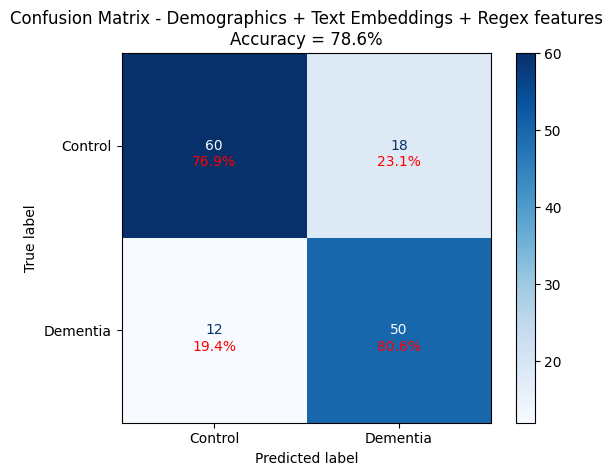

In [111]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
index = 3
label = list(models.keys())[index].split("(")[-1][:-1]
clf = final_models[index]
X_train, X_test = list(models.values())[index]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_pred = clf.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
cm_row_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create labels
labels = np.array([f"{count}\n({perc:.1%})" for count, perc in zip(cm.flatten(), cm_row_norm.flatten())]).reshape(cm.shape)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Control', 'Dementia'])

disp.plot(cmap=plt.cm.Blues, values_format='d')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f"\n\n{cm_row_norm[i, j]:.1%}", ha="center", va="center", color="red", fontsize=10)

accuracy = results_df.iloc[index]['Accuracy']
plt.title(f'Confusion Matrix - {label}\nAccuracy = {accuracy:.1%}')
plt.savefig(f"results/confusion_matrix_{label}.png")

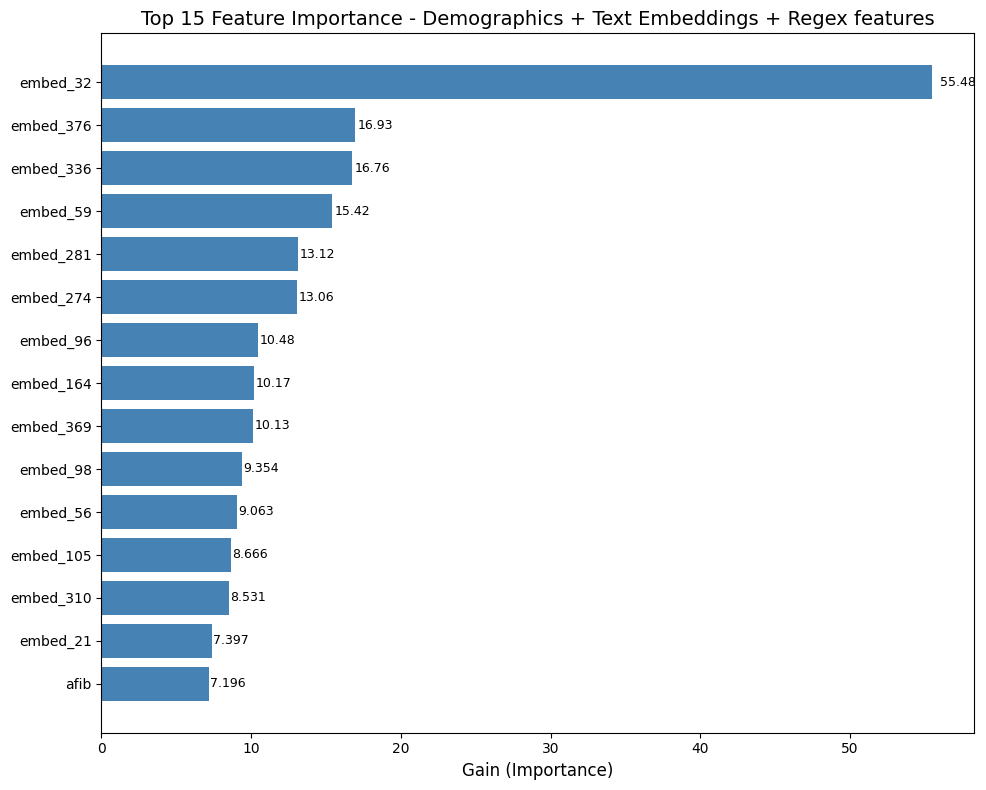

In [112]:
# Best model feature importance
index = 3
clf = final_models[index]
label = list(models.keys())[index].split("(")[-1][:-1]

embedding_names = [f"embed_{i}" for i in range(embeddings.shape[1])]
binary_cols = ["hypertension", "brain_injury", "diabetes", "depression", "smoking", "obesity", "afib", "stroke", "alcohol"]

all_feature_names = ["age_years", "sex_M"] + embedding_names + binary_cols

clf.get_booster().feature_names = all_feature_names
importance_dict = clf.get_booster().get_score(importance_type='gain')

# Convert to DataFrame
importance_df = pd.DataFrame({
    'feature': list(importance_dict.keys()),
    'importance': list(importance_dict.values())
}).sort_values('importance', ascending=False)

# Limit to top 15
importance_df = importance_df.head(15)

# Round to 4 significant figures
importance_df['importance'] = importance_df['importance'].apply(
    lambda x: float(f"{x:.4g}")  # 'g' format uses significant figures
)

plt.figure(figsize=(10, 8))

# Create horizontal bar chart (more readable for feature names)
bars = plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color='steelblue')

# Add value labels with 4 significant figures
for bar, val in zip(bars, importance_df['importance'][::-1]):
    plt.text(bar.get_width() + bar.get_width() * 0.01,
             bar.get_y() + bar.get_height()/2,
             f'{val:.4g}',  # 4 significant figures
             va='center', fontsize=9)

plt.xlabel('Gain (Importance)', fontsize=12)
plt.title(f'Top 15 Feature Importance - {label}', fontsize=14)
plt.tight_layout()
plt.savefig(f'results/feature_importance_{label}_named.png', dpi=150, bbox_inches='tight')
plt.show()